In [ ]:
# 필수 패키지 설치 (최초 1회만 실행)
# - langchain-upstage: UpstageDocumentParseLoader 등 Upstage 공식 통합
# - python-dotenv : .env 파일에서 API 키 로드
# - pillow        : PNG 렌더링용 PIL.Image
# !pip install -qU langchain-upstage python-dotenv pillow

In [1]:
# === 표준 라이브러리 ===
import os                                       # 환경 변수·파일 경로
import base64                                   # Upstage 응답의 base64 이미지 디코딩
from collections import Counter                 # 카테고리 분포 확인
from pathlib import Path                        # 경로 객체

# === 외부 패키지 ===
from dotenv import load_dotenv                  # .env → os.environ 주입
from langchain_upstage import UpstageDocumentParseLoader  # Document Parse 통합

# .env에 있는 UPSTAGE_API_KEY, OPENAI_API_KEY 등을 로드
load_dotenv()

# macOS에서 FAISS + OpenMP 라이브러리 중복 로드 충돌 예방
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"


In [2]:
# 처리할 PDF 원본 (노트북 기준 상대 경로)
SAMPLE = "data/sample-report.pdf"

# 이미지·HTML·Markdown 산출물을 저장할 디렉터리
# 예: data/sample-report.pdf → data/sample-report/
OUTPUT_DIR = Path(os.path.splitext(SAMPLE)[0])
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)   # 없으면 생성, 있으면 무시
OUTPUT_DIR


PosixPath('data/sample-report')

## `UpstageDocumentParseLoader` 호출 (`split="element"`)

기본은 페이지 단위 분할이지만, 멀티모달 RAG에서는 요소 단위(`element`)가 검색 정밀도가
높습니다. `base64_encoding`에 이미지가 들어 있는 카테고리를 지정하면 응답 메타데이터에
그대로 base64가 실립니다.


In [3]:
# UpstageDocumentParseLoader는 /v1/document-digitization(document-parse) 엔드포인트를 내부적으로 호출
loader = UpstageDocumentParseLoader(
    file_path=SAMPLE,
    # split 옵션: "page" / "element" / "none"
    # "element" — paragraph/figure/chart/table 등을 요소 단위로 분리. 멀티모달 RAG에 유리
    split="element",
    # page_content 형식: "markdown" / "html" / "text"
    # 표·목록을 원형 그대로 받기 위해 markdown 사용
    output_format="markdown",
    coordinates=True,                             # 요소의 바운딩 박스 좌표를 metadata에 포함
    # figure/chart/table만 base64 이미지를 응답에 실어 보냄 (없으면 /image/placeholder로만 옴)
    base64_encoding=["figure", "chart", "table"],
    # "auto": 이미지에만 OCR, PDF 텍스트 레이어는 그대로 사용
    ocr="auto",
)

docs = loader.load()                              # 요소별 Document 리스트
print("총 요소 수:", len(docs))
print("카테고리 분포:", Counter(d.metadata.get("category") for d in docs))


총 요소 수: 512
카테고리 분포: Counter({'paragraph': 301, 'heading1': 72, 'footer': 52, 'header': 42, 'table': 24, 'chart': 14, 'figure': 6, 'list': 1})


In [4]:
# 첫 번째 figure/chart/table 요소를 뽑아 응답 구조를 살펴본다
image_doc = next(
    (d for d in docs if d.metadata.get("category") in {"figure", "chart", "table"}),
    None,
)
if image_doc:
    # base64_encoding은 수백 KB → 출력에 방해되므로 제외하고 나머지 metadata만 표시
    md_meta = {k: v for k, v in image_doc.metadata.items() if k != "base64_encoding"}
    print("metadata:", md_meta)
    print("base64 길이:", len(image_doc.metadata.get("base64_encoding", "")))
    print("page_content 미리보기:", image_doc.page_content[:200])


metadata: {'id': 14, 'page': 1, 'category': 'table', 'coordinates': [{'x': 0.5076, 'y': 0.2566}, {'x': 0.9235, 'y': 0.2566}, {'x': 0.9235, 'y': 0.6497}, {'x': 0.5076, 'y': 0.6497}]}
base64 길이: 132604
page_content 미리보기: | Bitumen prices at key locations, 25 Sep-1 Oct $/t | Bitumen prices at key locations, 25 Sep-1 Oct $/t | Bitumen prices at key locations, 25 Sep-1 Oct $/t | Bitumen prices at key locations, 25 Sep-1 


## base64 이미지 → 파일 저장

메타데이터에 들어 있는 base64 문자열을 PNG로 저장하고, 저장된 경로를 `image_path`로
메타데이터에 추가합니다. (`base64_encoding`은 용량이 크므로 메타데이터에서 제거.)


In [5]:
def save_base64_images(docs, output_dir: Path) -> list:
    """각 Document의 base64 이미지를 PNG로 저장하고 metadata를 갱신."""
    output_dir.mkdir(parents=True, exist_ok=True)

    # (페이지, 카테고리)별 순번 카운터 — 같은 페이지에 table이 여러 개면 1, 2, ... 부여
    counter: dict[tuple[int, str], int] = {}
    saved = []
    for d in docs:
        b64 = d.metadata.get("base64_encoding")
        if not b64:
            continue                              # 텍스트 요소는 이미지 없음 → 건너뜀

        page = d.metadata.get("page", 0)
        category = d.metadata.get("category", "figure")
        key = (page, category)
        counter[key] = counter.get(key, 0) + 1

        # 파일명 예: page_3_chart_1.png
        fname = f"page_{page}_{category}_{counter[key]}.png"
        fpath = output_dir / fname
        fpath.write_bytes(base64.b64decode(b64))  # base64 → PNG 바이너리

        # 메모리/토큰 절약: 무거운 base64는 제거, 파일 경로만 남김
        d.metadata.pop("base64_encoding", None)
        d.metadata["image_path"] = str(fpath)
        saved.append(str(fpath))
    return saved


saved_paths = save_base64_images(docs, OUTPUT_DIR)
print(f"{len(saved_paths)}개 이미지 저장됨 → {OUTPUT_DIR}")


44개 이미지 저장됨 → data/sample-report


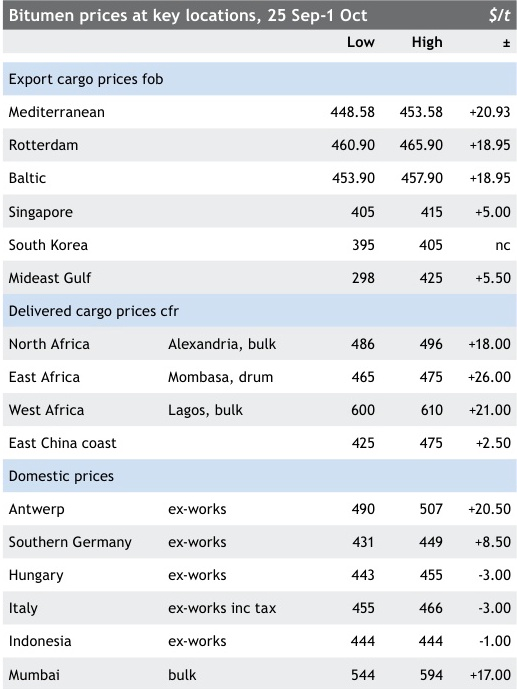

In [6]:
# 저장된 PNG 중 첫 번째를 노트북에 렌더링해 시각적 확인
from PIL import Image
if saved_paths:
    display(Image.open(saved_paths[0]))


## 통합 Markdown 산출

각 요소의 `page_content`를 그대로 이어 붙이면 그림 카테고리 항목은 저장된 파일을
참조하도록 보강할 수 있습니다.


In [7]:
import re

# Upstage 응답의 <img> 자리표시자 패턴: ![...](/image/placeholder)
# 이 패턴을 실제 저장한 파일명으로 치환하기 위해 사용
PLACEHOLDER_PAT = re.compile(r"!\[([^\]]*)\]\(([^)]+)\)")


def fix_image_links(text: str, rel_src: str, alt: str) -> str:
    """Upstage가 넣은 ![...](/image/placeholder)를 실제 파일명으로 치환.
    placeholder가 없으면 끝에 이미지 링크를 추가."""
    if PLACEHOLDER_PAT.search(text):
        # 첫 번째 매치만 치환 — 기존 alt 유지, 비어 있으면 카테고리명 사용
        return PLACEHOLDER_PAT.sub(
            lambda m: f"![{m.group(1) or alt}]({rel_src})", text, count=1
        )
    return f"{text}\n\n![{alt}]({rel_src})".strip()


# 모든 Document의 page_content를 이어 붙여 단일 마크다운 문서 생성
lines = []
for d in docs:
    text = d.page_content.strip()
    img_path = d.metadata.get("image_path")
    if img_path:
        # MD와 PNG가 같은 폴더에 있으므로 파일명만 상대 경로로 사용
        rel = Path(img_path).name
        text = fix_image_links(text, rel, d.metadata.get("category", "image"))
    if text:
        lines.append(text)

md_doc = "\n\n".join(lines)                     # 최종 통합 마크다운 문자열
md_path = OUTPUT_DIR / f"{Path(SAMPLE).stem}.md"
md_path.write_text(md_doc, encoding="utf-8")
print("Markdown 저장:", md_path)


Markdown 저장: data/sample-report/sample-report.md


## 분할 모드 비교 (옵션)

검색 단위를 페이지 단위로 묶고 싶을 때는 `split="page"`로 변경합니다. (재호출 비용
절감을 위해 평소엔 주석 처리하는 것을 권장.)


In [9]:
# page_loader = UpstageDocumentParseLoader(
#     file_path=SAMPLE,
#     split="page",
#     output_format="markdown",
#     coordinates=False,
# )
# page_docs = page_loader.load()
# print("페이지 수:", len(page_docs))
# print(page_docs[0].page_content[:300])


## 멀티모달 자연어 검색을 위한 텍스트화 (카테고리별 차등 처리)

실제 `md_doc`을 분석해보니 문서 특성이 다음과 같습니다.

- **table**: `chart_recognition` 덕분에 이미 완전한 마크다운 표로 추출됨 → 요약하면 오히려 수치 손실. **LLM 호출 불필요**.
- **chart**: 이미 `Chart Type` + 소형 데이터 표가 붙어 있음 → 이미지는 축/범례/추세/단위 보완에만 사용.
- **figure**: 텍스트 표현이 없음 → **비전 기반 설명이 필수**.
- 헤딩이 Upstage에서 자주 오분류되므로(본문 문장이 `#` 로 표시되는 케이스 다수) 헤더 기반 섹션 분할은 이 문서에는 부적합.

따라서 다음 전략을 씁니다.
1. **table**: 요소의 원본 마크다운(= `page_content`)을 그대로 description 으로 사용 + 바로 앞 한 줄 캡션 덧붙이기.
2. **chart / figure**: 바로 앞 캡션 + 같은 페이지 본문 텍스트를 컨텍스트로 GPT-4o-mini 비전 호출.

이 방식은 **LLM 호출을 ~40회에서 ~15회로 줄이면서** 표의 수치 정확도를 100% 보존합니다.


In [8]:
# === LangChain 컴포넌트 ===
from langchain_core.messages import HumanMessage
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI

# gpt-4o-mini — 비전 지원 + 저렴한 비용, 설명문 생성 용도로 충분
vision_llm = ChatOpenAI(model="gpt-4o-mini", temperature=0, max_tokens=600)

# 이미지 계열 카테고리
IMAGE_CATEGORIES = {"figure", "chart", "table"}

# 맥락 수집용 텍스트 카테고리 (heading1은 오분류가 많아 제외)
TEXT_CATEGORIES = {"paragraph", "caption", "list"}


def get_immediate_caption(docs, idx, max_chars: int = 150) -> str:
    """이미지 바로 앞 2개 요소 중 짧은 텍스트를 캡션으로 사용.

    차트/표 직전의 한 줄 제목을 잡기 위한 휴리스틱.
    예: "Rotterdam domestic differential to HSFO barges $/t"
    """
    for j in range(idx - 1, max(-1, idx - 3), -1):   # idx-1, idx-2 만 검사
        text = docs[j].page_content.strip()
        cat = docs[j].metadata.get("category")
        # 짧은 텍스트 요소(≤150자)만 캡션 후보로 인정
        if cat in TEXT_CATEGORIES and 0 < len(text) <= max_chars:
            return text
    return ""


def get_page_context(docs, idx, max_chars: int = 1500) -> str:
    """같은 페이지의 본문 텍스트 요소만 모아 컨텍스트로 사용 (자기 자신 제외).

    문자 예산(max_chars) 초과 시 중단.
    """
    target_page = docs[idx].metadata.get("page")
    parts, used = [], 0
    for j, d in enumerate(docs):
        if j == idx:
            continue                                 # 자기 자신 제외
        if d.metadata.get("page") != target_page:
            continue                                 # 다른 페이지 제외
        if d.metadata.get("category") not in TEXT_CATEGORIES:
            continue                                 # 헤딩·이미지 등 제외
        text = d.page_content.strip()
        if not text:
            continue
        if used + len(text) > max_chars:
            break                                    # 예산 초과 시 종료
        parts.append(text)
        used += len(text)
    return "\n\n".join(parts)


# === 이미지 설명 생성용 프롬프트 ===
# 교재의 ChatPromptTemplate.from_messages 패턴을 따라 시스템/휴먼 분리.
# 휴먼 메시지는 [text, image_url] 두 블록 → 멀티모달 입력.
describe_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "당신은 PDF 보고서의 시각 요소(이미지·차트·표)를 분석하여\n"
            "자연어 검색에 적합한 한국어 설명문을 작성하는 문서 분석 전문가입니다.\n"
            "이미지에서 확인되는 사실만 기술하고, 추정은 하지 마세요.",
        ),
        (
            "human",
            [
                # 동적으로 채워질 설명 프롬프트 (캡션·문맥 포함)
                {"type": "text", "text": "{user_prompt}"},
                # base64 이미지 (data URL 형식)
                {
                    "type": "image_url",
                    "image_url": {"url": "data:image/png;base64,{image_b64}"},
                },
            ],
        ),
    ]
)

# LCEL 체인: 프롬프트 → LLM → 문자열 파싱
describe_chain = describe_prompt | vision_llm | StrOutputParser()


In [11]:
def encode_image(path: str) -> str:
    """PNG 파일을 base64 문자열로 인코딩 (data URL 본문용)."""
    with open(path, "rb") as f:
        return base64.b64encode(f.read()).decode()


# 카테고리별 지시문 — LLM에게 무엇을 기술할지 구체적으로 지시
CATEGORY_INSTRUCTIONS = {
    "chart": "차트의 종류·축·범례·주요 수치 비교와 추세를 4~6문장으로 정리하세요.",
    "figure": "그림의 종류·시각 요소·핵심 메시지를 4~6문장으로 설명하세요.",
}


def describe_visual(
    image_path: str,
    category: str,
    caption: str,
    page_context: str,
    existing_text: str = "",
) -> str:
    """chart/figure 용 비전 설명 생성 (describe_chain 호출).

    여러 컨텍스트를 #Caption, #ExtractedText, #PageContext 섹션으로 묶어 프롬프트 구성.
    """
    # === 컨텍스트 섹션 구성 ===
    sections = [f"다음은 PDF 보고서의 [{category}]입니다."]
    if caption:
        sections.append(f"#Caption:\n{caption}")                  # 이미지 직결 캡션
    if existing_text:
        # 차트는 chart_recognition 덕에 소형 표가 함께 추출돼 있을 수 있음
        sections.append(f"#ExtractedText:\n{existing_text}")
    if page_context:
        sections.append(f"#PageContext:\n{page_context}")         # 같은 페이지 본문

    # === 지시문 + 형식 요구 ===
    sections.append(
        CATEGORY_INSTRUCTIONS[category]
        + "\n자연어 검색 질의에 잘 매칭되도록 핵심 키워드·수치·단위를 포함해 한국어로 작성하세요."
    )

    # 프롬프트 문자열과 이미지 base64를 체인에 전달
    return describe_chain.invoke(
        {
            "user_prompt": "\n\n".join(sections),
            "image_b64": encode_image(image_path),
        }
    )


def build_description(docs, idx) -> str:
    """카테고리별 분기: table은 원본 마크다운 재사용, chart/figure는 LLM 호출.

    table은 chart_recognition으로 이미 완전한 마크다운 표가 추출되어 있어
    LLM 요약보다 원문을 그대로 쓰는 편이 수치 정확도 100% + 비용 절감.
    """
    d = docs[idx]
    category = d.metadata["category"]
    caption = get_immediate_caption(docs, idx)

    if category == "table":
        body = d.page_content.strip()                             # 이미 완전한 MD 표
        # 캡션이 있으면 앞에 한 줄 붙임 → 검색 시 표 주제 매칭 보강
        return f"{caption}\n\n{body}".strip() if caption else body

    # chart / figure → 비전 LLM으로 설명 생성
    return describe_visual(
        image_path=d.metadata["image_path"],
        category=category,
        caption=caption,
        page_context=get_page_context(docs, idx),
        existing_text=d.page_content.strip(),
    )


In [12]:
# 카테고리별 설명 생성 루프
# - table           : LLM 호출 없이 원본 마크다운 재사용 (수치 보존)
# - chart / figure : GPT-4o-mini 비전 호출 (1 요소 = 1 호출)
from tqdm import tqdm

llm_calls = 0                                       # 실제 호출 횟수 집계
for i, d in enumerate(tqdm(docs, desc="이미지 설명 생성")):
    if d.metadata.get("category") not in IMAGE_CATEGORIES:
        continue                                    # 텍스트 요소 스킵
    if not d.metadata.get("image_path"):
        continue                                    # 이미지가 저장되지 않은 요소 스킵
    if d.metadata.get("description"):
        continue                                    # 이미 생성된 경우 재사용 (재실행 안전)

    d.metadata["description"] = build_description(docs, i)
    if d.metadata["category"] in {"chart", "figure"}:
        llm_calls += 1

print(f"LLM 호출 횟수: {llm_calls}")

# 카테고리별로 생성된 설명 샘플 하나씩 미리보기
for cat in ("table", "chart", "figure"):
    sample = next(
        (d for d in docs if d.metadata.get("category") == cat and d.metadata.get("description")),
        None,
    )
    if sample:
        print(f"\n===== [{cat} p.{sample.metadata['page']}] =====")
        print(sample.metadata["description"][:320], "...")


이미지 설명 생성:   0%|          | 0/518 [00:00<?, ?it/s]

이미지 설명 생성: 100%|██████████| 518/518 [01:13<00:00,  7.08it/s]

LLM 호출 횟수: 20

===== [table p.1] =====
| Bitumen prices at key locations, 25 Sep-1 Oct $/t | Bitumen prices at key locations, 25 Sep-1 Oct $/t | Bitumen prices at key locations, 25 Sep-1 Oct $/t | Bitumen prices at key locations, 25 Sep-1 Oct $/t |  |
| --- | --- | --- | --- | --- |
|  |  | Low | High | ± |
| Export cargo prices fob | Export cargo prices fo ...

===== [chart p.1] =====
차트는 로테르담에서 고황산유(HSFO) 바지선에 대한 국내 차이를 달러/톤($/t)으로 나타낸 선형 그래프입니다. 2021년 1월 22일에는 78%로 시작하여, 4월 16일에는 90%로 최고점을 기록했습니다. 이후 7월 9일에는 80%로 소폭 하락하였고, 10월 1일에는 70%로 다시 감소했습니다. 전반적으로 차트는 로테르담의 HSFO에 대한 프리미엄이 변동성을 보이며 감소하는 추세를 나타내고 있습니다. 주요 수치는 1월 22일 78%, 4월 16일 90%, 7월 9일 80%, 10월 1일 70%입니다. ...

===== [figure p.2] =====
이 그림은 "WATERBORNE BITUMEN PRICES, FOB"라는 제목 아래, 여러 지역의 수출 비트멘 가격을 나타내고 있습니다. 주요 가격 정보는 로테르담에서 톤당 463달러, 이탈리아 455달러, 그리스 455달러, 스페인 460달러, 한국 400달러, 대만 403달러, 태국 400달러, 이란 298달러, 바레인 425달러, 아이보리코스트 552달러, 싱가포르 410달러입니다. 이 데이터는 비트멘의 가격 변동을 시각적으로 비교할 수 있게 해주며, 특히 아이보리코스트의 가격이 가장 높은 점이 주목됩니다. 그림은 세계

## 텍스트 청크 분할 (overlap)

교재 권장값(`RecursiveCharacterTextSplitter`, 한글 문서 `chunk_size≈800`, overlap 10–15%)을
따라 paragraph 등 본문 텍스트를 분할합니다. **이미지 카테고리는 분할하지 않고**
GPT 설명문 한 덩어리를 그대로 색인합니다 (이미 자기 완결적 텍스트이므로).


In [13]:
# === MultiVectorRetriever의 2층 구조를 위한 문서 준비 ===
# - child_docs : 벡터 인덱스에 적재할 "검색용" 텍스트 (작은 청크 / 설명문)
# - parent_docs: child와 id_key로 연결되어, 검색 결과로 반환될 "원본" 문서
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
import uuid

# 교재(6-2_Chunking) 권장값 — 한국어 문서 기준 chunk_size≈800, overlap 10~15%
splitter = RecursiveCharacterTextSplitter(
    chunk_size=800,
    chunk_overlap=120,                             # ≈15%
    separators=["\n\n", "\n", " ", ""],         # 분리 우선순위 (큰 구분자부터)
)

id_key = "doc_id"                                  # child ↔ parent를 잇는 메타데이터 키
parent_docs: list[Document] = []                   # 검색 결과로 LLM에 전달할 원본
child_docs: list[Document] = []                    # 벡터 인덱스에 들어갈 검색용 텍스트

for d in docs:
    cat = d.metadata.get("category")
    parent_id = str(uuid.uuid4())                  # 매 요소마다 고유 ID 생성

    if cat in IMAGE_CATEGORIES:
        # === 이미지 계열 (table/chart/figure) ===
        # parent: description은 page_content로 두고, metadata 중복(description) 제거
        parent_meta = {k: v for k, v in d.metadata.items() if k != "description"}
        parent = Document(
            page_content=d.metadata.get("description", ""),
            metadata={**parent_meta, id_key: parent_id},
        )
        parent_docs.append(parent)

        # child: 동일한 설명문을 검색용으로 색인 (이미지는 분할하지 않음)
        child_docs.append(
            Document(
                page_content=d.metadata.get("description", ""),
                metadata={id_key: parent_id, "category": cat, "page": d.metadata.get("page")},
            )
        )
    else:
        # === 텍스트 계열 (paragraph/heading/list 등) ===
        # parent: 원문 통째로 보존
        parent = Document(page_content=d.page_content, metadata={**d.metadata, id_key: parent_id})
        parent_docs.append(parent)

        # child: overlap 분할로 여러 청크 생성 → 검색 정밀도 향상
        for chunk in splitter.split_text(d.page_content):
            if chunk.strip():
                child_docs.append(
                    Document(
                        page_content=chunk,
                        metadata={id_key: parent_id, "category": cat, "page": d.metadata.get("page")},
                    )
                )

print(f"부모(원본) 문서: {len(parent_docs)}개")
print(f"자식(검색용) 청크: {len(child_docs)}개")


부모(원본) 문서: 518개
자식(검색용) 청크: 518개


## Retriever 선택 — `MultiVectorRetriever`

교재 `06_RAG/6-5_Retriever/07-MultiVectorRetriever.ipynb` 에서 권장하는 패턴:
**"요약(또는 가상 질문)으로 검색하고 원문을 반환"**.

이 패턴이 멀티모달에 가장 잘 맞습니다.
- **검색용(child)** = GPT가 만든 자연어 설명문 + 본문 청크 → 자연어 질의에 잘 걸림
- **반환용(parent)** = 원본 요소(`image_path` 메타데이터 포함) → LLM에 그림을 그대로 전달

(보조로 한국어 검색을 강화하려면 `EnsembleRetriever(KiwiBM25 + FAISS)`를 그 앞에
얹는 구성이 교재 추천이지만, 이 노트북에서는 핵심 흐름을 명확히 하기 위해
MultiVectorRetriever 단독으로 진행합니다.)


In [14]:
from langchain_openai import OpenAIEmbeddings
from langchain_community.vectorstores import FAISS
from langchain.retrievers.multi_vector import MultiVectorRetriever
from langchain.storage import InMemoryStore

# OpenAI 경량 임베딩 — 품질/비용 균형
embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

# child_docs만 벡터 DB(FAISS)에 적재 → 자연어 질의에 대해 유사도 검색
vectorstore = FAISS.from_documents(child_docs, embeddings)

# parent_docs는 key-value 스토어에 id_key로 적재 → 검색 결과 원문 반환용
docstore = InMemoryStore()
docstore.mset([(p.metadata[id_key], p) for p in parent_docs])

# MultiVectorRetriever 패턴: 검색은 child로, 반환은 parent로
# - 이미지 카테고리의 parent에는 image_path가 그대로 실려 있어 멀티모달 LLM에 전달 가능
retriever = MultiVectorRetriever(
    vectorstore=vectorstore,
    docstore=docstore,
    id_key=id_key,
    search_kwargs={"k": 4},                         # 상위 4개 child → 해당 parent 반환
)

retriever


MultiVectorRetriever(vectorstore=<langchain_community.vectorstores.faiss.FAISS object at 0x1360b3e10>, docstore=<langchain_core.stores.InMemoryStore object at 0x1360e7090>, search_kwargs={'k': 4})

In [15]:
# 동작 확인 — 자연어 질의로 이미지 카테고리까지 검색되는지 확인
sample_query = "보고서에서 가장 인상적인 차트가 무엇이고 어떤 수치를 보여주나요?"
for d in retriever.invoke(sample_query):
    # 반환은 parent 단위 → image_path가 metadata에 포함됨
    print(f"[{d.metadata.get('category')} p.{d.metadata.get('page')}] image_path={d.metadata.get('image_path')}")
    print(d.page_content[:160], "...\n")


[chart p.20] image_path=data/sample-report/page_20_chart_1.png
차트는 바 차트 형식으로, 'Bespoke projects', 'Long-term', 'Mid-term', 'Short-term'의 네 가지 항목을 비교하고 있습니다. 각 항목의 수치는 모두 'Not specified'로 표기되어 있어 구체적인 수치는 제시되지 않았습니다. 차트는 각 프 ...

[chart p.1] image_path=data/sample-report/page_1_chart_1.png
차트는 로테르담에서 고황산유(HSFO) 바지선에 대한 국내 차이를 달러/톤($/t)으로 나타낸 선형 그래프입니다. 2021년 1월 22일에는 78%로 시작하여, 4월 16일에는 90%로 최고점을 기록했습니다. 이후 7월 9일에는 80%로 소폭 하락하였고, 10월 1일에는 70%로 다시  ...

[chart p.4] image_path=data/sample-report/page_4_chart_1.png
차트 제목은 "Southern Germany"이며, 선형 차트로 구성되어 있습니다. 차트는 2023년 1월 22일부터 10월 1일까지의 데이터를 보여주며, 주요 수치는 다음과 같습니다: 1월 22일 300, 4월 16일 350, 7월 9일 400, 10월 1일 375입니다. Southe ...

[chart p.2] image_path=data/sample-report/page_2_chart_1.png
차트는 2020년 10월 23일부터 2021년 10월 1일까지의 수송된 비투멘 가격을 나타내는 선형 차트입니다. 주요 도시 및 국가별 가격은 다음과 같습니다: 로테르담(130), 스페인(110), 이탈리아(100), 그리스(50), 아이보리코스트(30)입니다. 로테르담의 가격이 가장 높 ...



## 멀티모달 RAG 체인 구성

검색 결과에 이미지가 포함되면 **그림 자체를 GPT-4o에 함께 전달**해야 정확한 답이 나옵니다.
각 retrieved Document의 `image_path`를 base64로 인코딩하여 `image_url` 컨텐츠 블록으로
구성합니다.


In [16]:
# === 체인 구성에 필요한 모듈 ===
from operator import itemgetter
from pathlib import Path

from IPython.display import Image as IPImage, Markdown, display
from langchain_core.messages import HumanMessage
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.runnables import RunnableLambda, RunnablePassthrough

# 답변용 LLM — 이미지를 함께 해석해야 하므로 gpt-4o(비전 지원)
answer_llm = ChatOpenAI(model="gpt-4o", temperature=0)

# === 프롬프트 ===
# 교재의 ChatPromptTemplate.from_messages 패턴 + MessagesPlaceholder 구조.
# MessagesPlaceholder는 가변 길이 메시지(예: chat_history)를 주입할 때 쓰임 —
# 여기서는 텍스트+이미지 여러 장을 담은 동적 HumanMessage를 주입하는 용도.
rag_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "당신은 PDF 보고서를 분석하여 한국어로 답변하는 RAG 어시스턴트입니다.\n"
            "주어진 문맥(Context)과 첨부된 이미지를 근거로만 답변하세요.\n"
            "문맥에서 찾을 수 없는 정보는 '제공된 자료로는 알 수 없습니다.'라고 답하세요.\n"
            "표/차트의 수치는 텍스트와 이미지를 교차 검증해 정확히 인용하세요.",
        ),
        MessagesPlaceholder("user_message"),
    ]
)


def format_context(docs) -> str:
    """검색된 Document들을 #Context 본문으로 직렬화."""
    parts = []
    for i, d in enumerate(docs, start=1):
        cat = d.metadata.get("category", "text")
        page = d.metadata.get("page")
        # 출처 라벨(번호·카테고리·페이지) + 본문
        parts.append(f"[{i}] ({cat}, p.{page})\n{d.page_content}")
    return "\n\n".join(parts)


def build_user_message(inputs: dict) -> dict:
    """컨텍스트(텍스트) + 검색된 이미지들을 하나의 HumanMessage로 구성."""
    docs = inputs["docs"]
    question = inputs["question"]

    # 교재 스타일 섹션 레이아웃: #Context / #Question
    text = f"#Context:\n{format_context(docs)}\n\n#Question:\n{question}"

    # 컨텐츠 블록 리스트 — [text] + (image_url) * N
    content = [{"type": "text", "text": text}]
    for d in docs:
        if d.metadata.get("image_path"):
            b64 = encode_image(d.metadata["image_path"])
            content.append(
                {
                    "type": "image_url",
                    "image_url": {"url": f"data:image/png;base64,{b64}"},
                }
            )
    # MessagesPlaceholder("user_message")가 받을 수 있도록 dict로 래핑
    return {"user_message": [HumanMessage(content=content)]}


# === 서브 체인: 메시지 구성 → 프롬프트 → LLM → 문자열 ===
answer_chain = (
    RunnableLambda(build_user_message) | rag_prompt | answer_llm | StrOutputParser()
)

# === 전체 체인 ===
# 1) question → retriever → docs (결과 dict에 merge)
# 2) dict에 answer_chain 결과를 "answer" 키로 merge
# 최종 invoke 결과: {"question": ..., "docs": [...], "answer": "..."}
rag_chain = RunnablePassthrough.assign(
    docs=itemgetter("question") | retriever
) | RunnablePassthrough.assign(answer=answer_chain)


def ask(question: str, show_images: bool = True) -> dict:
    """질의 → LLM 답변(마크다운 렌더링)과 참고 이미지만 표시.

    반환값은 {"question", "docs", "answer"} dict — 후처리가 필요하면 활용.
    """
    result = rag_chain.invoke({"question": question})
    display(Markdown(result["answer"]))             # 답변 (마크다운 렌더링)
    if show_images:
        for d in result["docs"]:
            img_path = d.metadata.get("image_path")
            if img_path:
                display(IPImage(filename=img_path)) # 원본 이미지 표시
    return result


### 예시 질의


Southern Germany 차트(p.4)를 선택하여 요약하겠습니다.

이 차트는 2023년 1월 22일부터 10월 1일까지 Southern Germany의 비트멘 소비 추세를 나타내고 있습니다. 주요 수치는 1월 22일 300, 4월 16일 350, 7월 9일 400, 10월 1일 375입니다. 전반적으로 Southern Germany의 비트멘 소비는 상승세를 보이다가 10월 1일에 소폭 하락했습니다. 이 차트는 Northern Germany와의 비교를 통해 두 지역의 소비 추세를 시각적으로 나타내며, Southern Germany의 소비가 꾸준히 증가했음을 시사합니다.

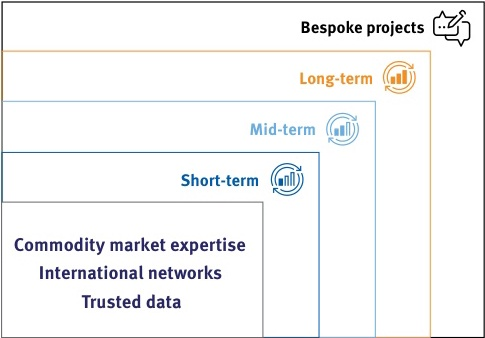

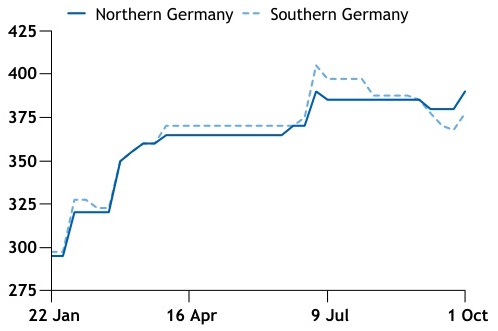

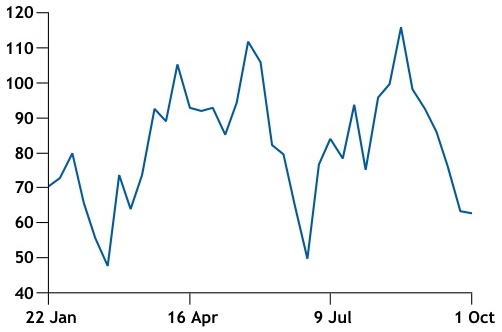

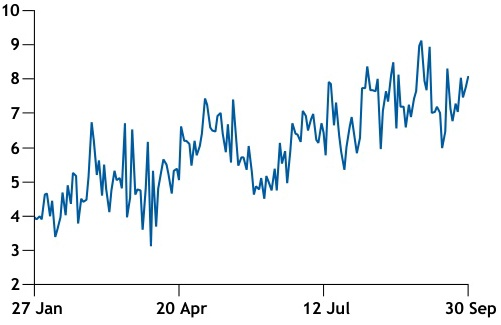

{'question': '보고서에 등장한 주요 차트 한 개를 골라 핵심 수치와 시사점을 한국어로 요약해줘.',
 'docs': [Document(metadata={'id': 193, 'page': 20, 'category': 'chart', 'coordinates': [{'x': 0.0872, 'y': 0.4601}, {'x': 0.4782, 'y': 0.4601}, {'x': 0.4782, 'y': 0.6532}, {'x': 0.0872, 'y': 0.6532}], 'image_path': 'data/sample-report/page_20_chart_1.png', 'doc_id': '2eb9e04f-5df7-4a3b-888b-5e048aa2f68c'}, page_content="차트는 바 차트 형식으로, 'Bespoke projects', 'Long-term', 'Mid-term', 'Short-term'의 네 가지 항목을 비교하고 있습니다. 각 항목의 수치는 모두 'Not specified'로 표기되어 있어 구체적인 수치는 제시되지 않았습니다. 차트는 각 프로젝트 유형에 대한 정보를 제공하며, 'Bespoke projects'가 가장 상위에 위치하고 있습니다. 이 차트는 프로젝트의 기간에 따른 분류를 나타내며, 각 항목의 중요성을 강조하고 있습니다. 주요 키워드는 'Bespoke projects', 'Long-term', 'Mid-term', 'Short-term'입니다."),
  Document(metadata={'id': 66, 'page': 4, 'category': 'chart', 'coordinates': [{'x': 0.0765, 'y': 0.6942}, {'x': 0.4773, 'y': 0.6942}, {'x': 0.4773, 'y': 0.8829}, {'x': 0.0765, 'y': 0.8829}], 'image_path': 'data/sample-report/page_4_chart_1.png', 'doc_id': '1597752a-5df8-

In [17]:
ask("보고서에 등장한 주요 차트 한 개를 골라 핵심 수치와 시사점을 한국어로 요약해줘.")

싱가포르의 바이튜먼 가격은 2023년 1월 22일에 325 USD에서 시작하여 4월 16일에 425 USD로 상승했습니다. 이후 7월 9일에는 400 USD로 소폭 하락한 후, 10월 1일에는 375 USD로 다시 감소하는 추세를 보였습니다. 전반적으로 가격은 300 USD에서 450 USD 사이에서 변동하며, 상승과 하락을 반복하는 패턴을 나타냈습니다. 이 가격 변동은 태국의 바이튜먼 가격과 유사한 추세를 보였습니다.

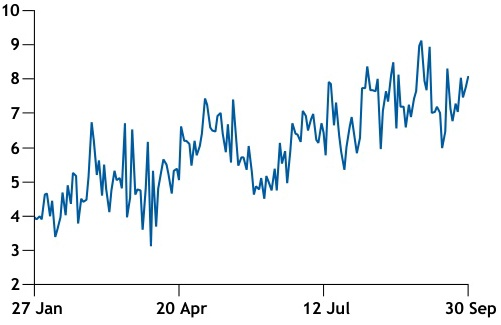

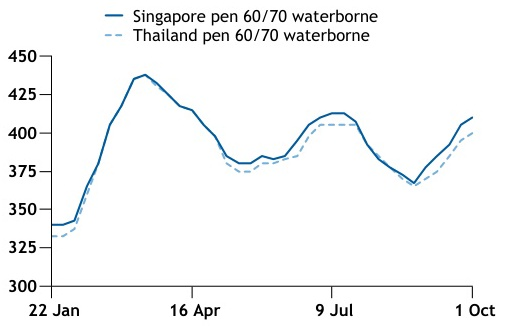

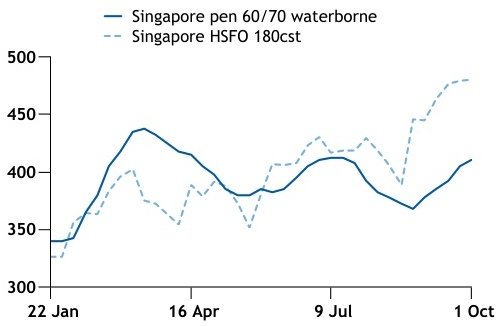

{'question': 'Singapore의 바이튜먼 가격은 표나 차트를 이용해 설명해',
 'docs': [Document(metadata={'id': 25, 'page': 21, 'category': 'chart', 'coordinates': [{'x': 0.5141, 'y': 0.6979}, {'x': 0.918, 'y': 0.6979}, {'x': 0.918, 'y': 0.8831}, {'x': 0.5141, 'y': 0.8831}], 'image_path': 'data/sample-report/page_21_chart_1.png', 'doc_id': '1dec58b8-e6fb-4a9d-8871-c0571702df53'}, page_content='차트는 2023년 1월부터 12월까지의 월별 가격 변동을 나타내는 선형 차트입니다. Y축은 가격을 나타내며 단위는 $/bl입니다. 데이터에 따르면, 1월의 가격은 4에서 시작하여 12월에는 8로 증가하는 추세를 보입니다. 특히 5월과 6월 사이에 가격이 7로 상승한 후, 9월에는 9에 도달하는 등 전반적으로 상승세를 유지하고 있습니다. 이 차트는 가격 변동의 전반적인 추세와 주요 수치를 시각적으로 비교할 수 있는 유용한 자료입니다.'),
  Document(metadata={'id': 171, 'page': 19, 'category': 'chart', 'coordinates': [{'x': 0.076, 'y': 0.6948}, {'x': 0.4827, 'y': 0.6948}, {'x': 0.4827, 'y': 0.8806}, {'x': 0.076, 'y': 0.8806}], 'image_path': 'data/sample-report/page_19_chart_1.png', 'doc_id': '4032d005-d3ad-4f1f-95f1-aafde95aae01'}, page_content='차트는 싱가포르와 태국의 60/70 비트멘 수출 가격을 비교한 선형 차트입니다. x축은 날짜(22 Jan, 16 Apr, 9

In [20]:
ask("Singapore의 바이튜먼 가격은 표나 차트를 이용해 설명해")